--------------------------------------------------
Título    : Relatório iniciação científica - Conversor Buck
Autor     : Luiz Felipe Souza de Lima Silva
Data      : 2026-04-29
--------------------------------------------------

## Dimensionamento do filtro buck

#### Indutor:

$$Lo = \frac{Vcarga\cdot (Vs - Vcarga)}{f\cdot \Delta I\cdot Vs}$$


Onde a $\Delta$ I é a faixa de ondulação de corrente;


- OBS.:

Considera-se uma ondulação de corrente que varie de 20% a 40% da corrente nominal, para que não ocorra uma possivel saturação;



---

#### Capacitor:

$$Co = \frac{\Delta I}{8 \cdot f \cdot \Delta Vc}$$


Onde $\Delta Vc$ é a faixa de ondulação da tensão;



Resistência de carga: 2.50 Ω
Potência máxima dissipada na carga: 90.00 W
Indutor de saída (Lo): 0.002500000000 H
Capacitor de saída (Co): 0.000100000000 F


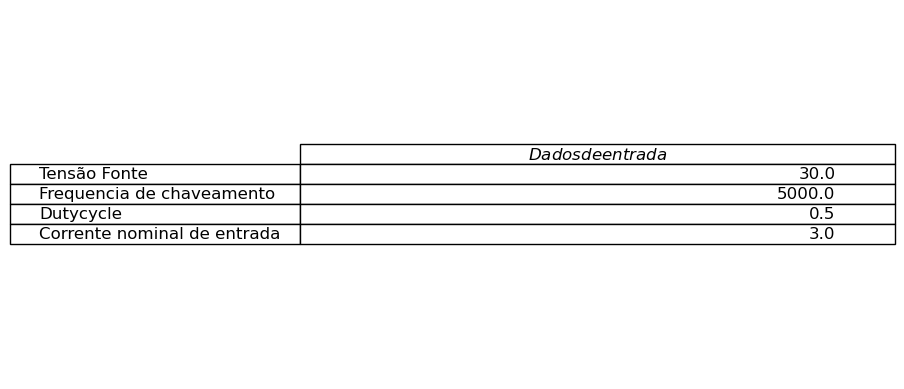

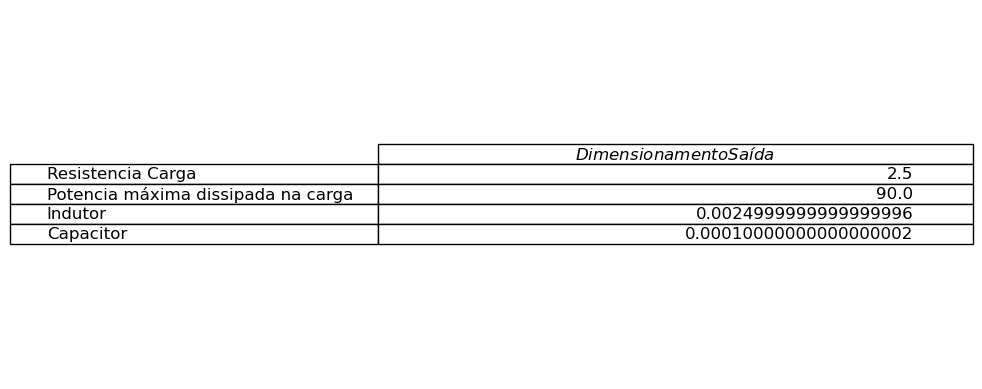

In [27]:
import numpy as np 
import matplotlib.pyplot as plt

Vs = float(input("Digite o valor de tensão na entrada (V): "))
f = float(input("Digite a frequência de chaveamento (Hz): "))
d = float(input("Digite o ciclo de trabalho (0-1): "))
i = float(input("Digite a corrente nominal de entrada (A): "))

Pmáx = Vs * i 
R = (d * Vs)**2 / Pmáx

print(f"Resistência de carga: {R:.2f} Ω")
print(f"Potência máxima dissipada na carga: {Pmáx:.2f} W")

##Parametrização dos indutores:
##Considerando uma corrente de ripple de 20% da corrente nominal de entrada
##Considerando uma tensão de ripple de 1% da tensão na de saída

Lo = ((d * Vs)*(Vs - (d * Vs))) / (f*(0.2*i)*Vs)
print(f"Indutor de saída (Lo): {Lo:.12f} H")

Co = (0.2*i) / (8 * f * (0.01*(d * Vs)))
print(f"Capacitor de saída (Co): {Co:.12f} F")


#-----------------------------------------------------------------------------

col_labels = [r'$Dados de entrada$']
row_labels = ['Tensão Fonte', 'Frequencia de chaveamento', 'Dutycycle', 'Corrente nominal de entrada']
table_vals = [
    [Vs],
    [f],
    [d],
    [i]
]
fig, ax = plt.subplots()

ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_vals,
                 colLabels=col_labels,
                 rowLabels=row_labels,
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

plt.show()

#------------------------------------------------------------------------------

col_labels = [r'$Dimensionamento Saída$']
row_labels = ['Resistencia Carga', 'Potencia máxima dissipada na carga', 'Indutor', 'Capacitor']
table_vals = [
    [R],
    [Pmáx],
    [Lo],
    [Co]
]
fig, ax = plt.subplots()

ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_vals,
                 colLabels=col_labels,
                 rowLabels=row_labels,
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)

plt.show()



## Diodo:

Para o dimensionamento ideal do diodo de roda livre considera-se principalmente seu tempo de recuperação, um bom tempo de recuperação é enssencial na aplicação de conversores de potência, permitindo previnir-se de um possivel curto circuitos e a queima de componentes.
Ademais, para evitar quedas de tensões elevadas garante-se que o diodo possua uma queda de tensão direta relativamente baixa.

